In [2]:
import pandas as pd
df = pd.read_csv("noticias_terca.csv", sep=",", encoding="utf-8")
print('\nMostrando os 5 primeiros registros:')
pd.options.display.max_columns = None
print(df.head(5))


Mostrando os 5 primeiros registros:
     typetarget  fellingtarget  \
0      acidente             -1   
1  desmatamento              1   
2   preservação              1   
3         geral              0   
4         geral              1   

                                               title  \
0  Filme brasileiro em realidade virtual sobre de...   
1  Brasil mobiliza mais de 200 contribuições para...   
2  GT de Sustentabilidade Ambiental e Climática d...   
3  COP 30 no Brasil: guia explica o Acordo de Par...   
4  O Banco Mundial e as tendências sobre o preço ...   

                                                text  \
0  O cineasta e videoartista brasileiro Tadeu Jun...   
1  Em busca de transformar promessas em ações con...   
2  Os ministérios do Meio Ambiente e Mudança do C...   
3  Em novembro de 2025, Belém recebe o maior even...   
4  Ambiente Jurídico O Banco Mundial e as tendênc...   

                                                 url  
0       https://news.un.org/p

In [3]:
print('\nMostrando as informações do DataFrame:')
df.info()
print('\nMostrando Labels:')
print(df['fellingtarget'].value_counts())


Mostrando as informações do DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   typetarget     700 non-null    str  
 1   fellingtarget  700 non-null    int64
 2   title          699 non-null    str  
 3   text           700 non-null    str  
 4   url            700 non-null    str  
dtypes: int64(1), str(4)
memory usage: 1.9 MB

Mostrando Labels:
fellingtarget
 1    296
-1    278
 0    126
Name: count, dtype: int64


In [4]:
print(df.query("typetarget == 'poluição' and fellingtarget == 1").head())

   typetarget  fellingtarget  \
10   poluição              1   
11   poluição              1   
16   poluição              1   
47   poluição              1   
55   poluição              1   

                                                title  \
10  Com gargalos na coleta seletiva e baixo índice...   
11  Copasa avança na agenda climática e integra Ín...   
16  Relatório alerta para impactos crescentes do c...   
47  Como o Brasil poderia melhorar a destinação do...   
55  Reciclagem com catadores gera até 10 vezes mai...   

                                                 text  \
10  Para muitos, pôr o saco de lixo na porta de ca...   
11  A Copasa foi incluída na carteira 2026 do Índi...   
16  O ano de 2024 foi o mais quente já registrado ...   
47  1 de 1 Cada brasileiro produz em média um quil...   
55  Compartilhe esta notícia:\n\nWhatsapp\n\nEnqua...   

                                                  url  
10  https://oglobo.globo.com/um-so-planeta/noticia...  
11  https

<Axes: >

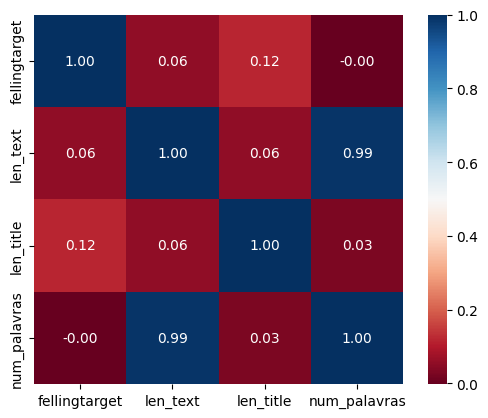

In [5]:
# Mostrando correlação entre variáveis
df['len_text'] = df['text'].str.len()
df['len_title'] = df['title'].str.len()
df['num_palavras'] = df['text'].str.split().apply(len)
import seaborn as sns
import numpy as np
df_correlacao = df.corr(numeric_only=True)
sns.heatmap(df_correlacao, cmap='RdBu'
, fmt='.2f', square=True, annot=True)

In [6]:
# Separando os dados de teste (30%) e de treino (70%)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Retirando as 4 colunas menos importantes
x_data = df.drop(["typetarget"
,
"fellingtarget"
,
"title"
,
"text"
,
"url"], axis=1, inplace=False)
y_data = df["typetarget"]
x_train, x_test, y_train, y_test = train_test_split(
x_data, y_data, test_size=0.3, random_state=42)
# NORMALIZAÇÃO: Crucial para algoritmos sensíveis à escala
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
print("x train: "
, x_train.shape)
print("x test: "
, x_test.shape)
print("y train: "
, y_train.shape)
print("y test: "
, y_test.shape)
print("✓ Dados normalizados com sucesso!")

x train:  (490, 3)
x test:  (210, 3)
y train:  (490,)
y test:  (210,)
✓ Dados normalizados com sucesso!


In [7]:
# Verificar e remover valores NaN
print("Verificando valores NaN nos dados...")
print(f"NaNs em x_train: {np.isnan(x_train).sum()}")
print(f"NaNs em x_test: {np.isnan(x_test).sum()}")

# Remover linhas com NaN
mask_train = ~np.isnan(x_train).any(axis=1)
mask_test = ~np.isnan(x_test).any(axis=1)

x_train = x_train[mask_train]
x_test = x_test[mask_test]
y_train = y_train[mask_train]
y_test = y_test[mask_test]

print(f"\nApos remover NaNs:")
print(f"x train: {x_train.shape}")
print(f"x test: {x_test.shape}")
print(f"y train: {y_train.shape}")
print(f"y test: {y_test.shape}")
print("✓ NaNs removidos com sucesso!")

Verificando valores NaN nos dados...
NaNs em x_train: 1
NaNs em x_test: 0

Apos remover NaNs:
x train: (489, 3)
x test: (210, 3)
y train: (489,)
y test: (210,)
✓ NaNs removidos com sucesso!


In [8]:
# Relatório de Desempenho com Validação Cruzada
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from time import time
def mostrar_desempenho(x_train, y_train, x_test, y_test, model, name):
    # Treinando modelo
    inicio = time()
    model.fit(x_train, y_train)
    fim = time()
    tempo_treinamento = (fim - inicio)*1000
    # Prevendo dados
    inicio = time()
    y_predicted = model.predict(x_test)
    fim = time()
    tempo_previsao = (fim - inicio)*1000
    # Validação Cruzada (5-fold)
    cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')
    print('='*60)
    print('Relatório Utilizando Algoritmo:', name)
    print('='*60)
    print('\nMostrando Matriz de Confusão:')
    print(confusion_matrix(y_test, y_predicted))
    print('\nMostrando Relatório de Classificação:')
    print(metrics.classification_report(y_test, y_predicted))
    accuracy = accuracy_score(y_test, y_predicted)
    print('Accuracy (teste):', accuracy)
    print('Accuracy (validação cruzada 5-fold):', f"{cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    relatorio = metrics.classification_report(y_test, y_predicted, output_dict=True)
    print('Precision:', relatorio['macro avg']['precision'])
    print('Tempo de treinamento (ms):', tempo_treinamento)
    print('Tempo de previsão (ms):', tempo_previsao)
    return accuracy, tempo_treinamento, tempo_previsao

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
model_mlp = MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=10000)
acc_mlp, tt_mlp, tp_mlp = mostrar_desempenho(
x_train, y_train, x_test, y_test, model_mlp, 'MLP')

Relatório Utilizando Algoritmo: MLP

Mostrando Matriz de Confusão:
[[ 0  0  5 15  5]
 [ 0  9  3 22 17]
 [ 0  6  7  6 17]
 [ 0  8  7 21 14]
 [ 0  4  8 13 23]]

Mostrando Relatório de Classificação:
              precision    recall  f1-score   support

    acidente       0.00      0.00      0.00        25
desmatamento       0.33      0.18      0.23        51
       geral       0.23      0.19      0.21        36
    poluição       0.27      0.42      0.33        50
 preservação       0.30      0.48      0.37        48

    accuracy                           0.29       210
   macro avg       0.23      0.25      0.23       210
weighted avg       0.26      0.29      0.26       210

Accuracy (teste): 0.2857142857142857
Accuracy (validação cruzada 5-fold): 0.3272 (+/- 0.0400)
Precision: 0.22840510366826156
Tempo de treinamento (ms): 714.1988277435303
Tempo de previsão (ms): 0.7383823394775391


c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metri

In [10]:
# Classificação com DecisionTree
from sklearn import tree
model_arvore = tree.DecisionTreeClassifier()
acc_dt, tt_dt, tp_dt = mostrar_desempenho(
x_train, y_train, x_test, y_test, model_arvore,
'DecisionTree')

Relatório Utilizando Algoritmo: DecisionTree

Mostrando Matriz de Confusão:
[[ 1  1  8  9  6]
 [ 7  9 10 13 12]
 [ 2  7  8  6 13]
 [ 6 11 17 10  6]
 [ 3 11 15 10  9]]

Mostrando Relatório de Classificação:
              precision    recall  f1-score   support

    acidente       0.05      0.04      0.05        25
desmatamento       0.23      0.18      0.20        51
       geral       0.14      0.22      0.17        36
    poluição       0.21      0.20      0.20        50
 preservação       0.20      0.19      0.19        48

    accuracy                           0.18       210
   macro avg       0.17      0.17      0.16       210
weighted avg       0.18      0.18      0.18       210

Accuracy (teste): 0.1761904761904762
Accuracy (validação cruzada 5-fold): 0.2495 (+/- 0.0187)
Precision: 0.16506347028914692
Tempo de treinamento (ms): 2.8972625732421875
Tempo de previsão (ms): 0.13756752014160156


In [11]:
# Classificação com RandomForest
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(max_depth=10, n_estimators=100, max_features='sqrt', random_state=42)
acc_rf, tt_rf, tp_rf = mostrar_desempenho(
x_train, y_train, x_test, y_test, model_rf, 'RandomForest')

Relatório Utilizando Algoritmo: RandomForest

Mostrando Matriz de Confusão:
[[ 1  1  7 12  4]
 [ 7  5  9 20 10]
 [ 1  3 12  5 15]
 [ 6  5 12 17 10]
 [ 2  6 11 11 18]]

Mostrando Relatório de Classificação:
              precision    recall  f1-score   support

    acidente       0.06      0.04      0.05        25
desmatamento       0.25      0.10      0.14        51
       geral       0.24      0.33      0.28        36
    poluição       0.26      0.34      0.30        50
 preservação       0.32      0.38      0.34        48

    accuracy                           0.25       210
   macro avg       0.22      0.24      0.22       210
weighted avg       0.24      0.25      0.24       210

Accuracy (teste): 0.2523809523809524
Accuracy (validação cruzada 5-fold): 0.3047 (+/- 0.0435)
Precision: 0.2242891164562991
Tempo de treinamento (ms): 89.41411972045898
Tempo de previsão (ms): 5.199909210205078


In [12]:
# Classificação com AdaBoost
from sklearn.ensemble import AdaBoostClassifier
acc_ada, tt_ada, tp_ada = mostrar_desempenho(
x_train, y_train, x_test, y_test, AdaBoostClassifier(), 'AdaBoost')

Relatório Utilizando Algoritmo: AdaBoost

Mostrando Matriz de Confusão:
[[ 0  0  2 12 11]
 [ 0  2  3 22 24]
 [ 0  1  5  8 22]
 [ 0  2  2 29 17]
 [ 0  0  3 17 28]]

Mostrando Relatório de Classificação:
              precision    recall  f1-score   support

    acidente       0.00      0.00      0.00        25
desmatamento       0.40      0.04      0.07        51
       geral       0.33      0.14      0.20        36
    poluição       0.33      0.58      0.42        50
 preservação       0.27      0.58      0.37        48

    accuracy                           0.30       210
   macro avg       0.27      0.27      0.21       210
weighted avg       0.30      0.30      0.24       210

Accuracy (teste): 0.3047619047619048
Accuracy (validação cruzada 5-fold): 0.3374 (+/- 0.0563)
Precision: 0.2674777183600713
Tempo de treinamento (ms): 58.020591735839844
Tempo de previsão (ms): 2.780437469482422


c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metri

In [13]:
# Classificação com KNN
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=5, p=2)
acc_knn, tt_knn, tp_knn = mostrar_desempenho(
x_train, y_train, x_test, y_test, model_knn, 'KNN')

Relatório Utilizando Algoritmo: KNN

Mostrando Matriz de Confusão:
[[ 2  3  3 13  4]
 [ 6  5 12 19  9]
 [ 1  7 13  7  8]
 [ 8  5 13 17  7]
 [ 4  5 18 11 10]]

Mostrando Relatório de Classificação:
              precision    recall  f1-score   support

    acidente       0.10      0.08      0.09        25
desmatamento       0.20      0.10      0.13        51
       geral       0.22      0.36      0.27        36
    poluição       0.25      0.34      0.29        50
 preservação       0.26      0.21      0.23        48

    accuracy                           0.22       210
   macro avg       0.21      0.22      0.20       210
weighted avg       0.22      0.22      0.21       210

Accuracy (teste): 0.22380952380952382
Accuracy (validação cruzada 5-fold): 0.2412 (+/- 0.0321)
Precision: 0.20649326326187337
Tempo de treinamento (ms): 3.4782886505126953
Tempo de previsão (ms): 2.447366714477539


In [14]:
# Classificação com Regressão Logística
from sklearn.linear_model import LogisticRegression
acc_lr, tt_lr, tp_lr = mostrar_desempenho(
x_train, y_train, x_test, y_test, LogisticRegression(), 'LR')

Relatório Utilizando Algoritmo: LR

Mostrando Matriz de Confusão:
[[ 0  0  0 17  8]
 [ 0  0  0 37 14]
 [ 0  0  0 11 25]
 [ 0  0  0 37 13]
 [ 0  0  0 20 28]]

Mostrando Relatório de Classificação:
              precision    recall  f1-score   support

    acidente       0.00      0.00      0.00        25
desmatamento       0.00      0.00      0.00        51
       geral       0.00      0.00      0.00        36
    poluição       0.30      0.74      0.43        50
 preservação       0.32      0.58      0.41        48

    accuracy                           0.31       210
   macro avg       0.12      0.26      0.17       210
weighted avg       0.14      0.31      0.20       210

Accuracy (teste): 0.30952380952380953
Accuracy (validação cruzada 5-fold): 0.3293 (+/- 0.0194)
Precision: 0.12429210134128166
Tempo de treinamento (ms): 11.011362075805664
Tempo de previsão (ms): 0.1430511474609375


c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metri

In [15]:
# Classificação com SVM
from sklearn.svm import SVC
acc_svm, tt_svm, tp_svm = mostrar_desempenho(
x_train, y_train, x_test, y_test, SVC(), 'SVM')

Relatório Utilizando Algoritmo: SVM

Mostrando Matriz de Confusão:
[[ 0  0  0 13 12]
 [ 0  0  5 31 15]
 [ 0  0  7 10 19]
 [ 0  0  1 33 16]
 [ 0  1  3 22 22]]

Mostrando Relatório de Classificação:
              precision    recall  f1-score   support

    acidente       0.00      0.00      0.00        25
desmatamento       0.00      0.00      0.00        51
       geral       0.44      0.19      0.27        36
    poluição       0.30      0.66      0.42        50
 preservação       0.26      0.46      0.33        48

    accuracy                           0.30       210
   macro avg       0.20      0.26      0.20       210
weighted avg       0.21      0.30      0.22       210

Accuracy (teste): 0.29523809523809524
Accuracy (validação cruzada 5-fold): 0.2985 (+/- 0.0296)
Precision: 0.2004314110965487
Tempo de treinamento (ms): 8.970022201538086
Tempo de previsão (ms): 4.037618637084961


c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metri

In [16]:
# Classificação com GaussianNB
from sklearn.naive_bayes import GaussianNB
acc_gnb, tt_gnb, tp_gnb = mostrar_desempenho(
x_train, y_train, x_test, y_test, GaussianNB(), 'GaussianNB')

Relatório Utilizando Algoritmo: GaussianNB

Mostrando Matriz de Confusão:
[[ 0  0  1  6 18]
 [ 0  0  4 13 34]
 [ 0  0  2  6 28]
 [ 0  0  1  9 40]
 [ 0  0  1 10 37]]

Mostrando Relatório de Classificação:


c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

    acidente       0.00      0.00      0.00        25
desmatamento       0.00      0.00      0.00        51
       geral       0.22      0.06      0.09        36
    poluição       0.20      0.18      0.19        50
 preservação       0.24      0.77      0.36        48

    accuracy                           0.23       210
   macro avg       0.13      0.20      0.13       210
weighted avg       0.14      0.23      0.14       210

Accuracy (teste): 0.22857142857142856
Accuracy (validação cruzada 5-fold): 0.2639 (+/- 0.0500)
Precision: 0.1324872933153188
Tempo de treinamento (ms): 1.7254352569580078
Tempo de previsão (ms): 0.23221969604492188


c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [17]:
# Classificação com LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
acc_lda, tt_lda, tp_lda = mostrar_desempenho(
x_train, y_train, x_test, y_test, LinearDiscriminantAnalysis(), 'LDA')

Relatório Utilizando Algoritmo: LDA

Mostrando Matriz de Confusão:
[[ 0  0  0 17  8]
 [ 0  4  0 32 15]
 [ 0  2  0 11 23]
 [ 0  5  0 32 13]
 [ 0  1  0 21 26]]

Mostrando Relatório de Classificação:
              precision    recall  f1-score   support

    acidente       0.00      0.00      0.00        25
desmatamento       0.33      0.08      0.13        51
       geral       0.00      0.00      0.00        36
    poluição       0.28      0.64      0.39        50
 preservação       0.31      0.54      0.39        48

    accuracy                           0.30       210
   macro avg       0.18      0.25      0.18       210
weighted avg       0.22      0.30      0.21       210

Accuracy (teste): 0.29523809523809524
Accuracy (validação cruzada 5-fold): 0.3272 (+/- 0.0312)
Precision: 0.18448030539649488
Tempo de treinamento (ms): 10.217666625976562
Tempo de previsão (ms): 0.2627372741699219


c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metri

In [18]:
# Classificação com QDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
model_qda = QuadraticDiscriminantAnalysis()
acc_qda, tt_qda, tp_qda = mostrar_desempenho(
x_train, y_train, x_test, y_test, model_qda, 'QDA')

Relatório Utilizando Algoritmo: QDA

Mostrando Matriz de Confusão:
[[ 0  0  1 16  8]
 [ 0  8  3 28 12]
 [ 0  5  6  8 17]
 [ 0  6  4 27 13]
 [ 0  3  4 19 22]]

Mostrando Relatório de Classificação:
              precision    recall  f1-score   support

    acidente       0.00      0.00      0.00        25
desmatamento       0.36      0.16      0.22        51
       geral       0.33      0.17      0.22        36
    poluição       0.28      0.54      0.36        50
 preservação       0.31      0.46      0.37        48

    accuracy                           0.30       210
   macro avg       0.26      0.26      0.23       210
weighted avg       0.28      0.30      0.26       210

Accuracy (teste): 0.3
Accuracy (validação cruzada 5-fold): 0.3170 (+/- 0.0194)
Precision: 0.25560709132137704
Tempo de treinamento (ms): 15.307188034057617
Tempo de previsão (ms): 0.21123886108398438


c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metri

In [19]:
# Classificação com SGDClassifier (Modelo da IA em Produção)
# Nota: A IA usa TfidfVectorizer + SGDClassifier em um Pipeline
# Aqui testamos em features numéricas já normalizadas
from sklearn.linear_model import SGDClassifier
model_sgd = SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42)
acc_sgd, tt_sgd, tp_sgd = mostrar_desempenho(
x_train, y_train, x_test, y_test, model_sgd, 'SGDClassifier (IA em Produção)')


Relatório Utilizando Algoritmo: SGDClassifier (IA em Produção)

Mostrando Matriz de Confusão:
[[ 1  4  0 13  7]
 [ 0  8  0 26 17]
 [ 0  5  0  6 25]
 [ 2  9  0 25 14]
 [ 4  6  0 12 26]]

Mostrando Relatório de Classificação:
              precision    recall  f1-score   support

    acidente       0.14      0.04      0.06        25
desmatamento       0.25      0.16      0.19        51
       geral       0.00      0.00      0.00        36
    poluição       0.30      0.50      0.38        50
 preservação       0.29      0.54      0.38        48

    accuracy                           0.29       210
   macro avg       0.20      0.25      0.20       210
weighted avg       0.22      0.29      0.23       210

Accuracy (teste): 0.2857142857142857
Accuracy (validação cruzada 5-fold): 0.2843 (+/- 0.0301)
Precision: 0.19797400461966097
Tempo de treinamento (ms): 13.960838317871094
Tempo de previsão (ms): 0.16999244689941406


c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\moodnews\.venv\Lib\site-packages\sklearn\metri

C:\Users\Pedro\AppData\Local\Temp\ipykernel_26524\1748718105.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


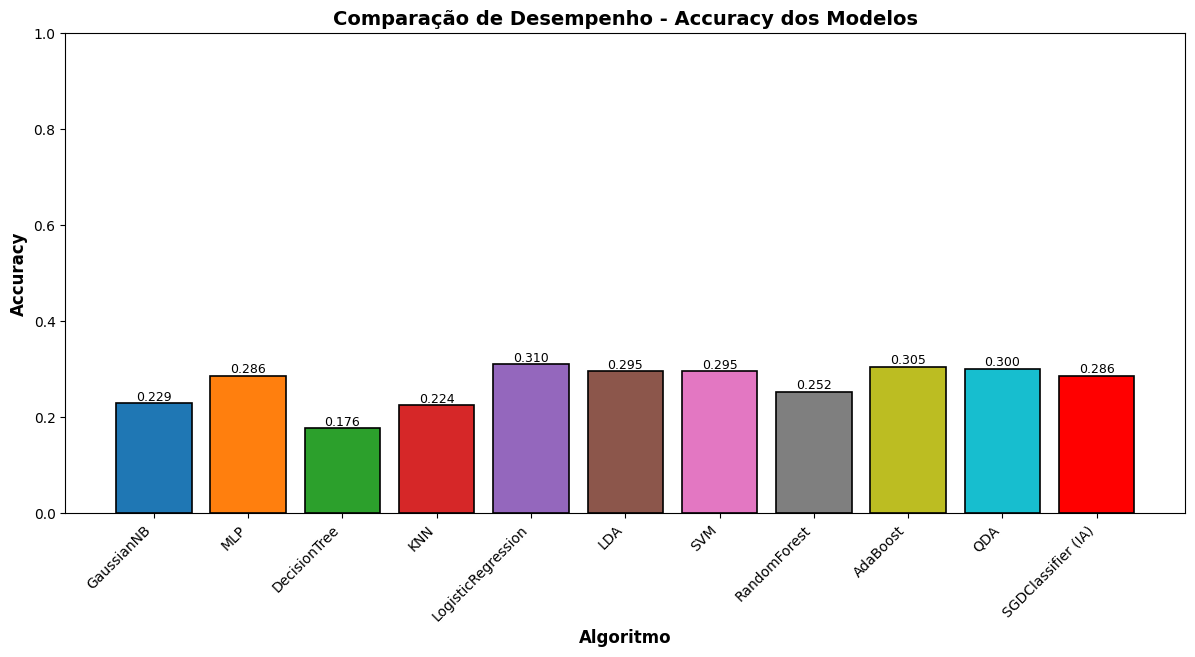

In [20]:
# Comparação de Desempenho em Accuracy
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(14, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
algoritmos = ['GaussianNB', 'MLP', 'DecisionTree', 'KNN', 'LogisticRegression', 'LDA', 'SVM', 'RandomForest', 'AdaBoost', 'QDA', 'SGDClassifier (IA)']
accs = [acc_gnb, acc_mlp, acc_dt, acc_knn, acc_lr, acc_lda, acc_svm, acc_rf, acc_ada, acc_qda, acc_sgd]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#ff0000']
bars = ax.bar(algoritmos, accs, color=colors, edgecolor='black', linewidth=1.2)
ax.set_xlabel('Algoritmo', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Comparação de Desempenho - Accuracy dos Modelos', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
plt.xticks(rotation=45, ha='right')
# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


C:\Users\Pedro\AppData\Local\Temp\ipykernel_26524\70417530.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


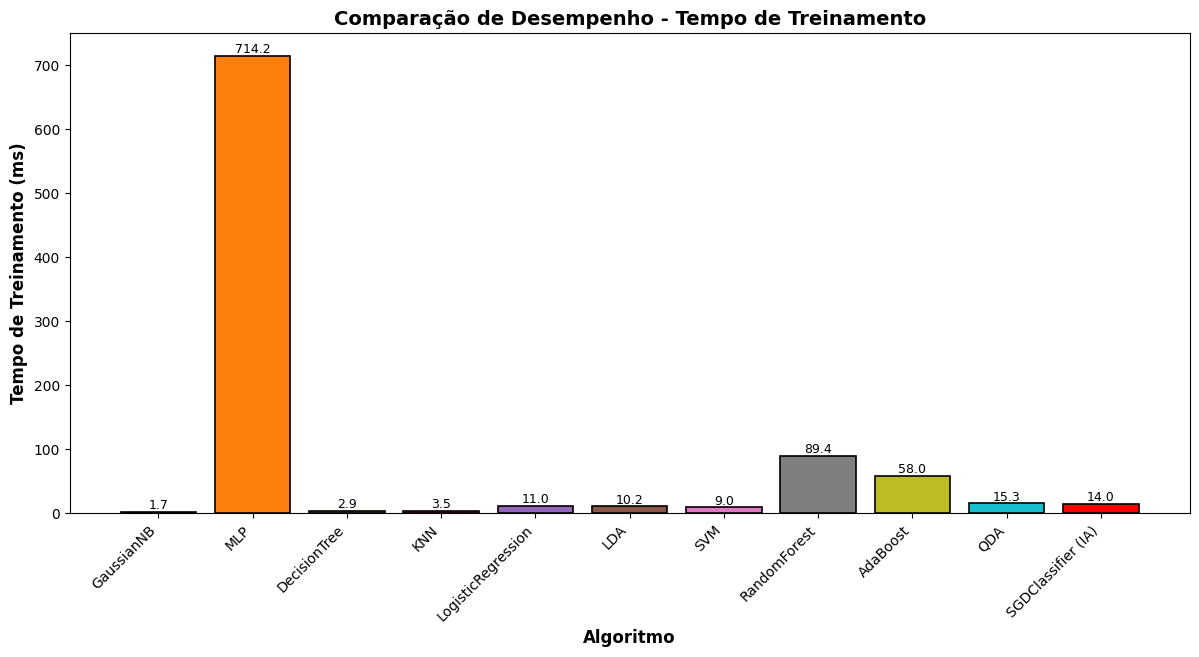

In [21]:
# Comparação de Desempenho em Tempo de Treinamento
fig = plt.figure(figsize=(14, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
tts = [tt_gnb, tt_mlp, tt_dt, tt_knn, tt_lr, tt_lda, tt_svm, tt_rf, tt_ada, tt_qda, tt_sgd]
bars = ax.bar(algoritmos, tts, color=colors, edgecolor='black', linewidth=1.2)
ax.set_xlabel('Algoritmo', fontsize=12, fontweight='bold')
ax.set_ylabel('Tempo de Treinamento (ms)', fontsize=12, fontweight='bold')
ax.set_title('Comparação de Desempenho - Tempo de Treinamento', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


C:\Users\Pedro\AppData\Local\Temp\ipykernel_26524\4162601151.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


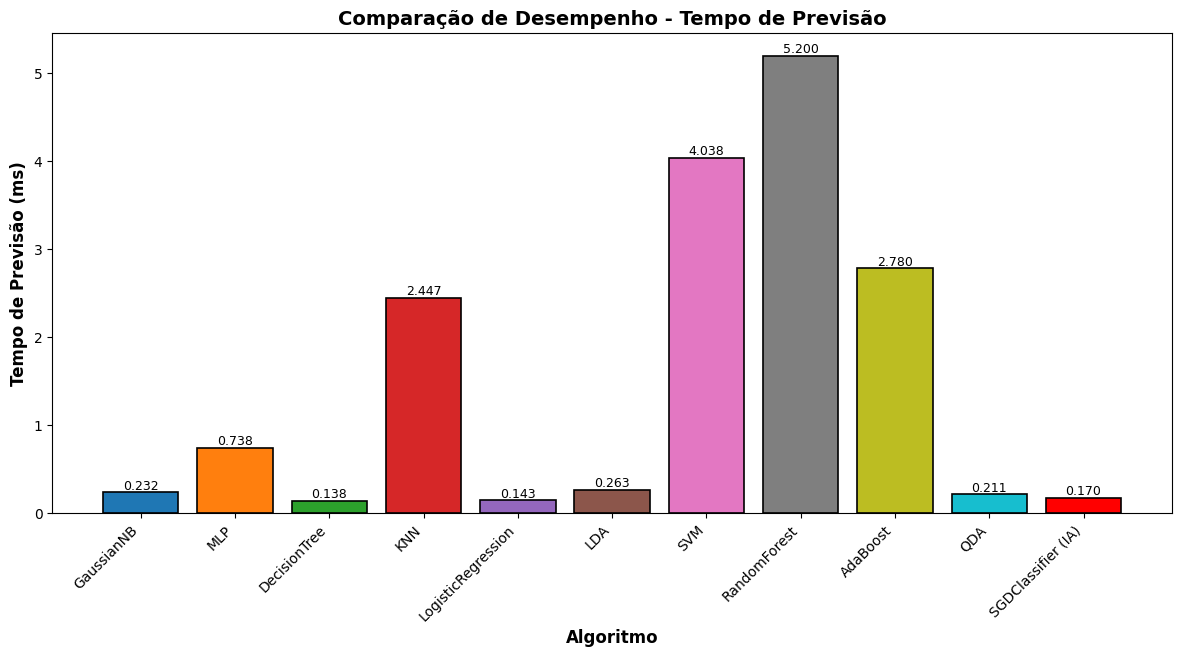

In [22]:
# Comparação de Desempenho em Tempo de Previsão
fig = plt.figure(figsize=(14, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
tps = [tp_gnb, tp_mlp, tp_dt, tp_knn, tp_lr, tp_lda, tp_svm, tp_rf, tp_ada, tp_qda, tp_sgd]
bars = ax.bar(algoritmos, tps, color=colors, edgecolor='black', linewidth=1.2)
ax.set_xlabel('Algoritmo', fontsize=12, fontweight='bold')
ax.set_ylabel('Tempo de Previsão (ms)', fontsize=12, fontweight='bold')
ax.set_title('Comparação de Desempenho - Tempo de Previsão', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
